# ML-testbed 05 — from one diagnostic to an experiment world

Factor becomes the application layer: it asks questions, calls tools and records evidence. ML-testbed is the workshop where we learn to build the models and interfaces behind those tools. This lesson turns “the experiment” into an explicit software contract.

Think of a model train set: the tracks are the simulator, the cameras are diagnostics, and the language model is a dispatcher. The dispatcher needs a map and a timetable before it can make useful decisions.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** dataclasses, validation, tensor dimensions, provenance, reproducible configuration, interface design

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

Matplotlib is building the font cache; this may take a moment.


PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. Draw the information flow
Machine configuration and uncertain material parameters produce a hidden trajectory. Each diagnostic observes that trajectory through its own response. Inference combines observations with assumptions. An LM can choose tools and explain their outputs; it does not get the hidden answer.

A **world model** predicts how state evolves under a configuration or action. A learned state-transition model arrives in lesson 10. The present simulator supplies a small world in which to learn.

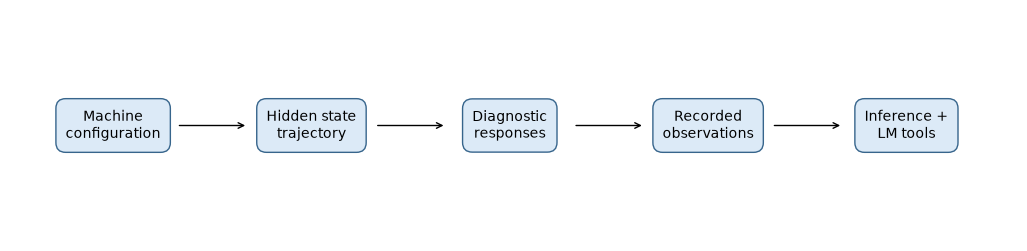

In [2]:
fig, ax = plt.subplots(figsize=(13,3)); ax.axis('off')
labels=['Machine\nconfiguration','Hidden state\ntrajectory','Diagnostic\nresponses','Recorded\nobservations','Inference +\nLM tools']
for i,label in enumerate(labels):
    ax.text(i*2.5,0,label,ha='center',va='center',bbox=dict(boxstyle='round,pad=.7',fc='#dceaf7',ec='#37658c'))
    if i<4: ax.annotate('',xy=(i*2.5+1.7,0),xytext=(i*2.5+.8,0),arrowprops=dict(arrowstyle='->'))
ax.set(xlim=(-1.3,11.4),ylim=(-1,1)); plt.show()

## 2. Separate machine, acquisition and inference settings
A PDV STFT window belongs to processing. Charge, load mass and circuit resistance belong to the physical model. Image exposure and channel clock offsets belong to acquisition. Priors and uncertainty models belong to inference. Keeping them separate lets us change one layer without silently changing the others.

In [3]:
machine=MachineConfig()
diagnostic=DiagnosticConfig(pdv_window=64, image_exposure=.04)
request={'schema_version':'world-request-v1','question':'infer charge and mass',
         'machine':asdict(machine),'diagnostics':asdict(diagnostic),
         'inference':{'method':'discrete_grid','parameters':['charge','mass'],
                      'prior':'uniform within declared bounds','calibration':'assumed known'},
         'agent':{'max_tool_calls':3,'allowed_tools':['infer','align','request_image']}}
print(json.dumps(request,indent=2)); print('Machine SHA256:',fingerprint(machine))

{
  "schema_version": "world-request-v1",
  "question": "infer charge and mass",
  "machine": {
    "charge": 1.0,
    "mass": 1.0,
    "resistance": 0.22,
    "growth": 0.6,
    "capacitance": 1.0,
    "inductance": 0.7,
    "coupling": 0.12,
    "damping": 0.08,
    "thermal_loss": 0.15,
    "end_time": 1.4,
    "samples": 96
  },
  "diagnostics": {
    "gain": 1.0,
    "clock_shift": 0.0,
    "blur_samples": 0.6,
    "noise": 0.015,
    "pdv_wavelength": 0.01,
    "pdv_window": 64,
    "image_psf_pixels": 1.0,
    "image_exposure": 0.04,
    "radiation_response": 1.0,
    "missing": []
  },
  "inference": {
    "method": "discrete_grid",
    "parameters": [
      "charge",
      "mass"
    ],
    "prior": "uniform within declared bounds",
    "calibration": "assumed known"
  },
  "agent": {
    "max_tool_calls": 3,
    "allowed_tools": [
      "infer",
      "align",
      "request_image"
    ]
  }
}
Machine SHA256: ee7b1910fe5a8befe4219e51d7951badedce9a7a73be58875ef58dd72c490f2a


### Visual lab — Who owns each setting?

Follow one question across the four layers. **Blue** settings change the synthetic machine; **orange** settings change what is recorded; **purple** settings change the analysis; **green** settings change how tools are used. A PDV window belongs to processing even when a software configuration stores it alongside acquisition fields.

**Predict:** if you change gain, should the hidden physical trajectory move?

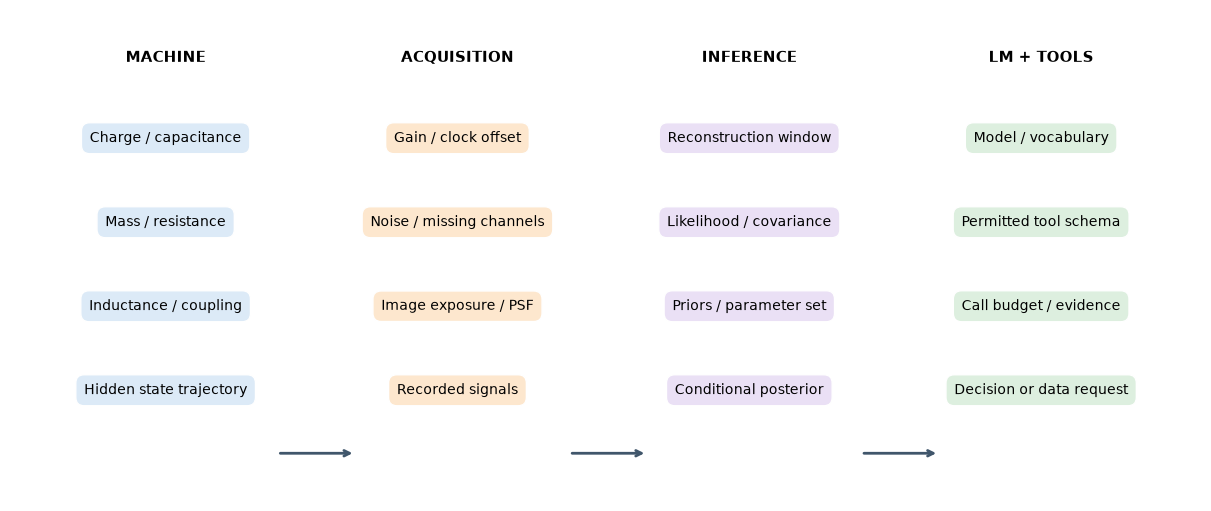

In [4]:
v_fig,v_ax=plt.subplots(figsize=(12,5),layout='constrained'); v_ax.axis('off')
v_columns=[('MACHINE','#dceaf7',['Charge / capacitance','Mass / resistance','Inductance / coupling','Hidden state trajectory']),
           ('ACQUISITION','#fde7ce',['Gain / clock offset','Noise / missing channels','Image exposure / PSF','Recorded signals']),
           ('INFERENCE','#eae0f5',['Reconstruction window','Likelihood / covariance','Priors / parameter set','Conditional posterior']),
           ('LM + TOOLS','#ddefdf',['Model / vocabulary','Permitted tool schema','Call budget / evidence','Decision or data request'])]
for v_j,(v_title,v_color,v_items) in enumerate(v_columns):
    v_x=v_j*3
    v_ax.text(v_x,4.25,v_title,ha='center',weight='bold',fontsize=11)
    for v_i,v_item in enumerate(v_items):
        v_ax.text(v_x,3.45-v_i*.88,v_item,ha='center',va='center',fontsize=10,
                  bbox=dict(boxstyle='round,pad=.6',fc=v_color,ec='white'))
    if v_j<3: v_ax.annotate('',xy=(v_x+1.95,.15),xytext=(v_x+1.15,.15),arrowprops=dict(arrowstyle='->',color='#40566b',lw=2))
v_ax.set(xlim=(-1.6,10.65),ylim=(-.35,4.8)); plt.show()

## 3. Make invalid configurations fail visibly
An invalid sample count or nonpositive mass should fail at the boundary. A valid configuration only means the software accepts it; it does not establish that the physical assumptions are sound.

In [5]:
for bad in [dict(mass=-1),dict(samples=4),dict(end_time=5)]:
    try: MachineConfig(**bad)
    except ValueError as exc: print('Rejected:',bad,'→',exc)
changed=replace(machine,mass=1.15)
assert fingerprint(changed)!=fingerprint(machine)
print('Changing mass changes the configuration fingerprint.')

Rejected: {'mass': -1} → mass must be finite and positive
Rejected: {'samples': 4} → samples must be an integer >= 16
Rejected: {'end_time': 5} → teaching solver is restricted to the pre-stagnation interval <= 1.6
Changing mass changes the configuration fingerprint.


## 4. Inspect one shot as tensors
`states.shape = [batch, time, variables]`. A batch is a collection of independent shots, not repeated frames from one shot. We will keep the same convention throughout the course.

time: (96,) states: (1, 96, 6)
{'capacitor_voltage': 0.03646371513605118, 'current': 0.9610069394111633, 'radius': 0.9790025949478149, 'inward_speed': 0.04609968513250351, 'thermal_proxy': 0.26256251335144043, 'perturbation': 0.012141329236328602}


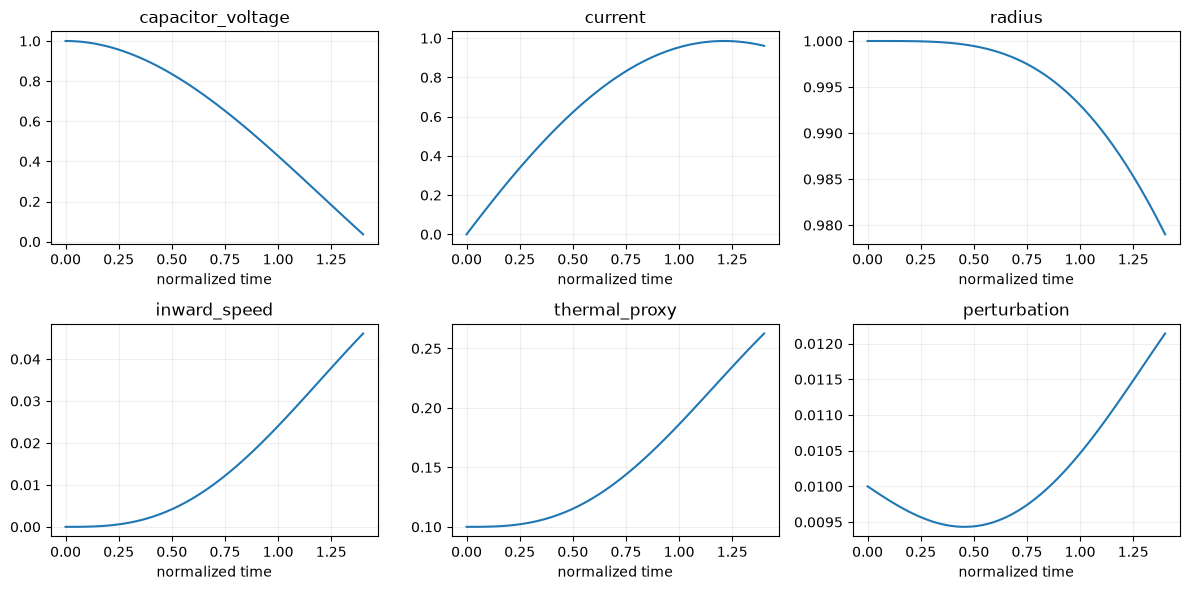

In [6]:
t,states=simulate()
print('time:',tuple(t.shape),'states:',tuple(states.shape))
print(dict(zip(STATE_NAMES,states[0,-1].tolist())))
fig,axes=plt.subplots(2,3,figsize=(12,6))
for j,ax in enumerate(axes.flat):
    ax.plot(t,states[0,:,j]); ax.set(title=STATE_NAMES[j],xlabel='normalized time')
plt.tight_layout(); plt.show()

## 5. Give the candidate observations, keep truth in the evaluator
The notebook author can inspect both objects. The tool interface accepts only the observation object. This is an API boundary, not an operating-system security boundary. True adversarial isolation would need separate processes and access controls.

In [7]:
public=observe(t.numpy(),states[0].numpy(),diagnostic,seed=501)
evaluator={'theta':asdict(machine),'state':states[0].numpy()}
assert 'state' not in public and 'theta' not in public
print('Public keys:',list(public)); print('Channels:',list(public['diagnostics']))
print('Image tensor:',public['diagnostics']['image']['intensity'].shape)
print('Candidate is never passed evaluator.')

Public keys: ['schema_version', 'units', 'diagnostics', 'acquisition', 'seed']
Channels: ['bdot', 'pdv', 'radiation', 'spectrum', 'image']
Image tensor: (4, 64, 96)
Candidate is never passed evaluator.


### Visual lab — What does a batch of shots look like?

Each row is an independent shot. Each column is a time sample. Color shows how a state changes through the batch. Every panel has its own color scale because current, radius and perturbation have different ranges.

**Notice:** frames from one row are related. Randomly distributing those frames across training and evaluation leaks information about the same shot.

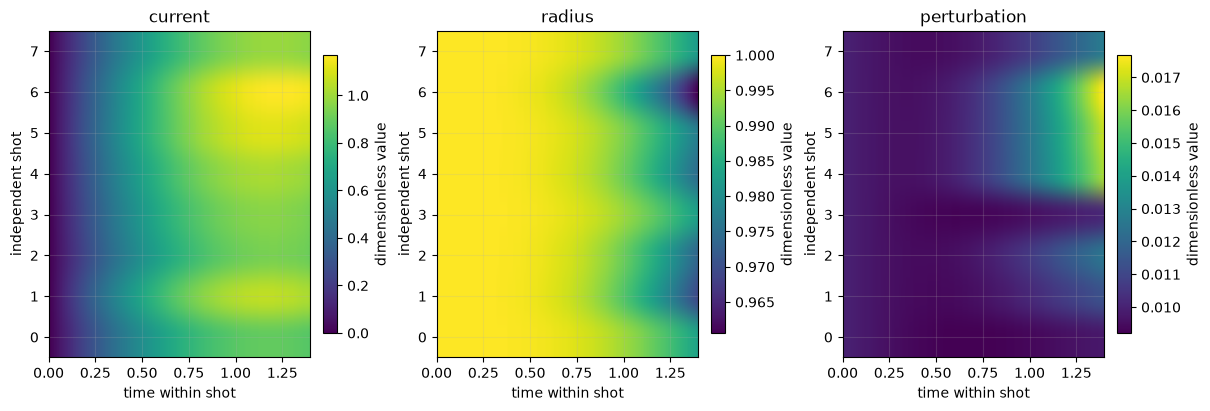

In [8]:
with torch.no_grad():
    v_parameters=draw_parameters(8,50501); v_time,v_batch=simulate(v_parameters)
v_fig,v_axes=plt.subplots(1,3,figsize=(12,4),layout='constrained')
for v_ax,v_col in zip(v_axes,[1,2,5]):
    v_im=v_ax.imshow(v_batch[:,:,v_col].numpy(),aspect='auto',origin='lower',extent=[0,float(v_time[-1]),-.5,7.5],cmap='viridis')
    v_ax.set(xlabel='time within shot',ylabel='independent shot',title=STATE_NAMES[v_col].replace('_',' '))
    v_fig.colorbar(v_im,ax=v_ax,shrink=.85,label='dimensionless value')
plt.show()

## 6. Record a reproducible contract
Each run gets a fresh directory, a configuration and source fingerprints. An experiment record should eventually include raw-data hashes, calibration versions, training data, model revision, tool trace, and the decision. This lesson starts that contract.

In [9]:
run=save_run(ROOT,'05',{'channels':list(public['diagnostics']),'state_shape':list(states.shape)},request)
(run/'request.json').write_text(json.dumps(request,indent=2))
print('Saved:',run)

Saved: /Users/operator/Desktop/Factor/runs/world-model/05-e3bf68d10a


## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Add a voltage-monitor configuration field and decide which layer owns it.
2. Change two machine settings and explain why their diagnostic effects might be confused.
3. Design an observation schema for a second laboratory without changing the agent interface.